### **DISCRETE MODEL**

By Marta Santomé Ferragut

A *Discrete Optimization* is the process of finding the best possible solution from a finite or countable set of distinct options, where the decision variables are restricted to discrete values such as integers, binary choices (0 or 1), or other specific items rather than continuous ranges.



---

**<h4>Exercise: Dicrete clustering</h4>**

<u><h5> Problem Statement </h5></u>

A city wants to place $k = 3$ ambulance stations to serve $n = 10$ neighborhoods. Each neighborhood must be assigned to one and only one of the selected stations. The goal is to minimize the total response distance between neighborhoods and their assigned station.

Key constraints:
- Ambulance stations can only be located in existing neighborhoods (not in arbitrary geographic coordinates).
- Every neighborhood must be served by one selected station.

This is a discrete clustering problem: choosing $k$ actual data points (station locations) and assigning the rest to their nearest one.

<u><h5>Formulation in Practice</h5></u>

- $N = {1, ..., 10}$ be neighborhoods.
- $d_{ij} =$ road distance (in km or minutes) from neighborhood $i$ to neighborhood $j$.
- Decision variable $y_j = 1$ if an ambulance station is placed at neighborhood $j, 0$ otherwise.
- $x_{ij} = 1$ if neighborhood $i$ is assigned to the station at $j, 0$ otherwise.

*Constraints*
- Each neighhood must be served by one station:
$$ \sum_{j=1}^{10} x_{ij} = 1 , \forall i$$
- Assignments only allowed to selected station locations:
$$ x_{ij} \leq y_i , \forall i,j $$
- Exactly 3 stations are selected:
$$ \sum_{j=1}^{10} y_j = 3 $$
- Binary variables:
$$ x_{ij}, y_j  \in\{0, 1\}$$

*Objective*

Minimize total response time:
$$ Minimize Z = \sum_{i=1}^{10} \sum_{j=1}^{10} d_{ij} · x_{ij} $$

---



I have searched for a library different from `pulp` library as I have used in the _LinearProgramming.ipynb_ work, so now I am going to use the `discrete_optimization` library.

I tried using the `discrete_optimization` library, but it won't let me; I'm getting errors. So, I'll use the `ortools` library instead.

Why use the `ortools` library?

OR-Tools (Operations Research Tools) is an open-source library developed by Google for solving discrete and continuous optimization problems.

It supports discrete variables and is good for the following:
- facility location
- resource allocation
- discrete clustering

In [ ]:
import math

import discrete_optimization
import numpy as np
from networkx.classes import neighbors

help(discrete_optimization) # library that I was going to use at the beginning


Help on package discrete_optimization:

NAME
    discrete_optimization

DESCRIPTION
    #  Copyright (c) 2022 AIRBUS and its affiliates.
    #  This source code is licensed under the MIT license found in the
    #  LICENSE file in the root directory of this source tree.

PACKAGE CONTENTS
    binpack (package)
    coloring (package)
    datasets
    facility (package)
    fjsp (package)
    generic_rcpsp_tools (package)
    generic_tasks_tools (package)
    generic_tools (package)
    gpdp (package)
    jsp (package)
    knapsack (package)
    maximum_independent_set (package)
    rcpsp (package)
    rcpsp_multiskill (package)
    singlemachine (package)
    tsp (package)
    tsptw (package)
    vrp (package)
    workforce (package)

VERSION
    0.7.0

FILE
    c:\users\mar1s\appdata\local\packages\pythonsoftwarefoundation.python.3.11_qbz5n2kfra8p0\localcache\local-packages\python311\site-packages\discrete_optimization\__init__.py




In [ ]:
import ortools

help(ortools) # library i'm going to use

Help on package ortools:

NAME
    ortools - # OR-Tools

DESCRIPTION
    This is the reference documentation for Google OR-Tools.
    
    This repository contains several component:
    
    ### Link with the C++ layer
     - `ortools.init.python.init`,
    
    ### Knapsack solver
     - `ortools.algorithms.python.knapsack_solver`,
    
    ### Graph and flow algorithms
    - `ortools.graph.python.linear_sum_assignment`,
    - `ortools.graph.python.max_flow`,
    - `ortools.graph.python.min_cost_flow`,
    
    ### Routing library and legacy Constraint Programming Solver
     - `ortools.constraint_solver.pywrapcp`,
    
    ### Minimalistic linear solver wrapper
    - `ortools.linear_solver.python.model_builder`
    
    ### CP-SAT
     - `ortools.sat.python.cp_model`,
     - `ortools.util.python.sorted_interval_list`,
     - `ortools.sat.cp_model_pb2`
     - `ortools.sat.sat_parameters_pb2`
    
    ### Legacy linear solver wrapper
     - `ortools.linear_solver.pywraplp`,
     - `or

What I am going to do is create a dictionary of `neighborhoods` that includes the name of each neighborhood in Madrid along with its GPS coordinates (latitude and longitude). From there, I will use the Haversine formula to calculate the actual distance between two neighborhoods in kilometers, which will allow me to obtain a much more intuitive representation of how the neighborhoods of Madrid are spatially related.

&nbsp;

**_Haversine:_**

The haversine function is a mathematical formula used to calculate the actual distance between two points on Earth using their coordinates (latitude and longitude).


City 1 :
- Latitud 1: $Lt_1$
- Longitud 1: $Lg_1$

City 2 :
- Latitud 2: $Lt_2$
- Longitud 2: $Lg_2$

$$Haversine = 2*r*sen^{(-1)}(\sqrt{sen^2(\frac{Lt_1 - Lt_2}{2})*cos(Lt_1)*cos(Lt_2)*sen^2(\frac{Lg_2 - Lg_1}{2})}$$

In [ ]:
# 1. DESIGN THE DATA

from itertools import product
import math

# Coordinates of Madrid neighborhoods (latitude, longitude)
neighborhoods = {
    'Palacio' : (40.4153295, -3.7147092),
    'Imperial' : (40.4057995, -3.7186854),
    'Recoletos' : (40.4243637, -3.6857429),
    'El Viso' : (40.4448882, -3.6847127),
    'Gaztambide' : (40.4349358, -3.7147092),
    'Los Cármenes' : (40.3958933, -3.7434461),
    'Comillas' : (40.3937574, -3.7116516),
    'Bellas Vistas' : (40.4526848, -3.7072396),
    'Casa de Campo' : (40.4241907, -3.755858),
    'Entrevías' : (40.3790449, -3.6717573)
}

nodes = sorted(neighborhoods.keys()) # list of the names of the neighborhoods (strings)
n = 10 # number of neighborhoods

neighborhood_names = list(nodes) # copy of the names of the neighborhoods in form of list

# Dictionary that associates the entire index with GPS coordinates of each neighborhood
coords = {i: neighborhoods[name] for i, name in enumerate(nodes)}

# We use the Haversine function to calculate the actual distance between two points on Earth using their coordinates
def haversine(p, q):
    """
    Haversine Function

    This function calculates the distance in kilometers between two points of the Earth's surface given by their coordinates using the Haversine formula.

    Args:
        p (tuple): first point coordinate (latitude, longitude)
        q (tuple): second point coordinate (latitude, longitude)

    Returns:
        Surface distance between the two points in kilometers.
    """
    R = 6371.0088 # average radius of the Earth in km

    # Converting degrees to radians
    lat1, lon1 = math.radians(p[0]), math.radians(p[1])
    lat2, lon2 = math.radians(q[0]), math.radians(q[1])
    dlat = lat2 - lat1 # latitude difference
    dlon = lon2 - lon1 # longitude difference

    # Haversine's Formula
    a = math.sin(dlat/2.0)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2.0)**2
    a = max(0.0, min(1.0, a))
    return 2 * R * math.asin(math.sqrt(a))

In [ ]:
# We created a dictionary of distances between all pairs of neighborhoods
distances = {}

# Build NumPy array of distances (for MDS)
distances_np = np.zeros((n, n), dtype=float)

# We calculate the distance between each pair of neighborhoods using the Haversine formula
for i, j in product(range(n), range(n)):
    if i == j:
        d = 0.0
    else:
        d = haversine(coords[i], coords[j])
    distances[(i, j)] = d
    distances_np[i, j] = d

# Make the matrix symmetric,
symmetric_distances = (distances_np + distances_np.T) / 2.0
np.fill_diagonal(symmetric_distances, 0.0)  # Ensure the diagonal is 0

# Print the matrix
print("Matrix distances:\n")
print(symmetric_distances)


Matrix distances:

[[0.         5.19315784 6.56307205 2.09406564 8.72199914 2.07235719
  5.30266619 7.01937468 4.20156093 3.63690057]
 [5.19315784 0.         5.04586411 6.44627751 8.71291545 3.68215895
  3.75313028 3.31737824 3.62010189 5.93518794]
 [6.56307205 5.04586411 0.         6.12581197 3.75411117 4.58614687
  1.465518   2.70299771 2.41264264 4.04898548]
 [2.09406564 6.44627751 6.12581197 0.         7.40315778 2.7693072
  5.21166673 7.37572818 4.15321389 2.28388839]
 [8.72199914 8.71291545 3.75411117 7.40315778 0.         7.20067156
  4.96441916 6.35415166 5.43216588 5.17651319]
 [2.07235719 3.68215895 4.58614687 2.7693072  7.20067156 0.
  3.25725179 4.97654551 2.1801241  2.71902734]
 [5.30266619 3.75313028 1.465518   5.21166673 4.96441916 3.25725179
  0.         2.36843157 1.11187841 3.46975666]
 [7.01937468 3.31737824 2.70299771 7.37572818 6.35415166 4.97654551
  2.36843157 0.         3.25443974 5.82155577]
 [4.20156093 3.62010189 2.41264264 4.15321389 5.43216588 2.1801241
  1

What does the distance matrix represent?

1. Rows and columns:
    - Each row $i$ represents a source neighborhood.
    - Each column $j$ represents a destination neighborhood.
    - The value $d_{i,j}$ (in row $i$, column $j$) is the distance between neighborhood $i$ and neighborhood $j$.
2. Main Diagonal:
    - The values of the main diagonal ($d_{ii}$) are 0, because they represent the distance of a neighborhood from itself (there is no distance).
3. Symmetric:
    - The matrix is symmetric, so the distance from $i$ to $j$ is equal to the distance from $j$ to $i$.

OR-Tools supports several optimization solvers, allowing you to choose the most suitable one for each problem:
- SCIP: Open-source solver for MIP.
- Gurobi and CPLEX: Commercial solvers for large and complex problems.
- GLPK: Open-source solver for linear problems.

SCIP is the best because it guarantees that it can solve your ambulance station location model optimally and reliably.

In [ ]:
from ortools.linear_solver import pywraplp # para usar el solver de optimización antes de resolver el problema

solver = pywraplp.Solver.CreateSolver('SCIP') # crear la variable SCIP solver de optimización

**Explanation of the decision variables:**

- $y_j$ (decides how neighborhoods are assigned to the selected stations): This is a binary variable that can only take the values 0 or 1. If:

- $y_j = 1$: An ambulance station is placed in neighborhood $j$.

- $y_j = 0$: An ambulance station is not placed in neighborhood $j$.

- $x_{i,j}$ (decides where the stations are located): This is a binary variable that can only take the values $0$ or $1$. If:

- $x_{i,j} = 1$: Neighborhood $i$ is assigned to the station located in neighborhood $j$.

- $x_{i,j} = 0$: Neighborhood $i$ is not assigned to the station in neighborhood $j$.

The constraint: $x_{ij} \leq y_i , \forall i,j $. -->
Means that you can only assign a neighborhood $i$ to a station in neighborhood $j$ if there is a station in $j$ (that is, if $y_j=1$). But if y_j = 0, then x_{i,j} must be 0 for all $i$.

The **objective** is to minimize the total sum of the distances between each neighborhood and its assigned station, which is achieved by optimizing these variables.

In [ ]:
# CREATE VARIABLES (DECISION VARIABLES)

# Assignments of neighborhoods --> station
x = {} # will store all the decision variables x_ij
for i in range(n): # iterates the neighborhoods
    for j in range(n): # for each neighborhood i, iterate over all neighborhoods j
        x[i, j] = solver.BoolVar(f"x_{i}_{j}")
        # x_ij = 1: Neighborhood i assigned to station in neighborhood j

# Station Locations
y = {} # will store all decision variables y_j
for j in range(n):  # iterate over the neighborhoods j
    y[j] = solver.BoolVar(f"y_{j}")
    # y_j = 1: There is a station in neighborhood j


# The neighborhood has to be located in a place that cannot be in the middle. Ambulance stations can only be located in existing neighborhoods, not at intermediate or arbitrary points on the map

In [ ]:
# RESTRICTIONS

# Each neighborhood must be assigned to a station
for i in range(n):  # iterates over each neighborhood i
     solver.Add(solver.Sum([x[i, j] for j in range(n)]) == 1) # it adds a restriction that the sum of all variables x_ij for a fixed i and all j, since the sum must be equal to 1

# Neighborhoods can only be assigned to existing stations
for i in range(n): # iterates over each neighborhood i
    for j in range(n): # for each i, iterate over each possible station j
        solver.Add(x[i, j] <= y[j]) # Add a restriction that says: "The variable x_ij must be less than or equal to y_j"

# They must park exactly k stations
k = 3
solver.Add(solver.Sum([y[j] for j in range(n)]) == k) # Add all the variables y_j, the sum must equal k

<ortools.linear_solver.pywraplp.Constraint; proxy of <Swig Object of type 'operations_research::MPConstraint *' at 0x0000025E43DD5AD0> >

In [ ]:
# OBJECTIVE FUNCTION
solver.Minimize(solver.Sum(symmetric_distances[i, j] * x[i,j] for i in range(n) for j in range(n)))# Minimize the total sum of the distances between each neighborhood and its assigned ambulance station, multiplying each distance by the binary variable that indicates whether that assignment is active

In [ ]:
# RESOLVE THE PROBLEM
status = solver.Solve()

In [ ]:
# PRINT SOLUTION
if status == pywraplp.Solver.OPTIMAL: # If an optimal solution is found
    print("Optimization solution:")
    print(f"Minimum total distance: {solver.Objective().Value():.3f}") # minimum distance
    print("\nSelected stations:")
    selected_stations = []
    # Pass through all possible station locations
    for j in range(n):
        # If the station is activated in the result (value close to 1)
        if y[j].solution_value() > 0.5:
            selected_stations.append(j)
            # Shows each selected station and its neighborhood
            print(f"Station in neighborhood {j}: {neighborhood_names[j]}")

    print("\nNeighborhoods assignments --> station:")
    # For each neighborhood, we show which station it has been assigned to
    for i in range(n):
        for j in range(n):
            if x[i,j].solution_value() > 0.5:
                print(f"Neighborhood {i} ({neighborhood_names[i]}) "
                      f"attended by station {j} ({neighborhood_names[j]}) "
                      f"distance = {distances[(i,j)]:.3f} km")

# However, if the solver has not found an optimal solution to the problem
elif status == pywraplp.Solver.FEASIBLE:
    print("Factible solution founded (not need to use optimum)")
elif status == pywraplp.Solver.INFEASIBLE:
    print("No factible solution found.")
else:
    print("Unknown status")

Optimization solution:
Minimum total distance: 15.846

Selected stations:
Station in neighborhood 3: El Viso
Station in neighborhood 4: Entrevías
Station in neighborhood 6: Imperial

Neighborhoods assignments --> station:
Neighborhood 0 (Bellas Vistas) attended by station 3 (El Viso) distance = 2.094 km
Neighborhood 1 (Casa de Campo) attended by station 6 (Imperial) distance = 3.753 km
Neighborhood 2 (Comillas) attended by station 6 (Imperial) distance = 1.466 km
Neighborhood 3 (El Viso) attended by station 3 (El Viso) distance = 0.000 km
Neighborhood 4 (Entrevías) attended by station 4 (Entrevías) distance = 0.000 km
Neighborhood 5 (Gaztambide) attended by station 3 (El Viso) distance = 2.769 km
Neighborhood 6 (Imperial) attended by station 6 (Imperial) distance = 0.000 km
Neighborhood 7 (Los Cármenes) attended by station 6 (Imperial) distance = 2.368 km
Neighborhood 8 (Palacio) attended by station 6 (Imperial) distance = 1.112 km
Neighborhood 9 (Recoletos) attended by station 3 (El V

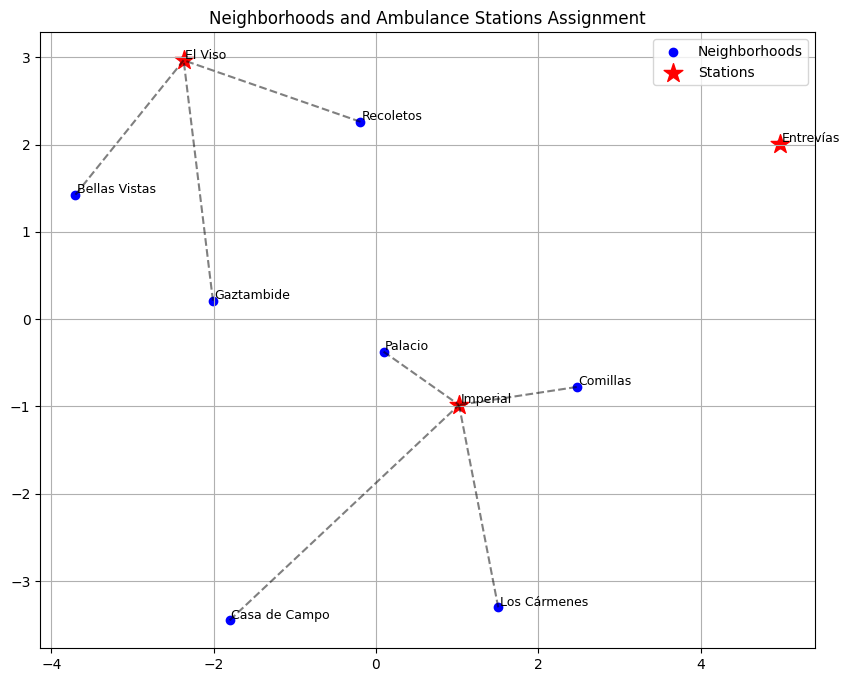

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import MDS

# Generate 2D coordinates using MDS (Multidimensional Scaling) : convert the (high-dimensional) distance matrix into 2D coordinates for visualization.
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(symmetric_distances)

# Visualization
plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], c='blue', label='Neighborhoods') # Plot all neighborhoods (blue dots) on the 2D coordinates generated by MDS

# Add neighborhood names next to each point
for i in range(n):
    plt.text(coords[i, 0] + 0.02,  # offset so it doesn't cover the dot
             coords[i, 1] + 0.02,
             neighborhood_names[i],
             fontsize=9)

# Highlight selected stations
selected_stations = [j for j in range(n) if y[j].solution_value() > 0.5]
# y[j].solution_value() > 0.5: identifies which points are stations (according to the optimization model)
plt.scatter(coords[selected_stations, 0], coords[selected_stations, 1], c='red', s=200, marker='*', label='Stations')
# graph these stations as large red stars (s=200, marker='*')

# Draw allocation lines: show which neighborhoods are assigned to each station.
for i in range(n):
    for j in range(n):
        if x[i, j].solution_value() > 0.5: # x[i, j].solution_value() > 0.5: checks if neighborhood i is assigned to station j
            plt.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]], 'k--', alpha=0.5) # plt.plot: draws a dotted line ('k--') between the neighborhood and its assigned station

plt.title("Neighborhoods and Ambulance Stations Assignment")
plt.legend()
plt.grid(True)
plt.show()

As we can see in the figure above, it represents neighborhoods and ambulance stations using their spatial coordinates, where the X-axis indicates horizontal position (east-west) and the Y-axis vertical position (north-south). Each blue dot corresponds to a neighborhood and each red star to a station, and the dotted lines show the assignment of each neighborhood to the nearest station, calculated using the Haversine formula between their coordinates.